<a href="https://colab.research.google.com/github/Nelson1798/NOAA/blob/main/01_Ground_QC_improved_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Focus Area 1 — Ground Observations Monitoring &amp; QC**
**Core Objective**: To equip NMHS participants with tools for quality-controlling ground station
data and validating it against satellite products, enabling identification of network issues and
building confidence in observational networks.

### **Overall notebook steps**
Set up
  - Step 1: Define variables to use in the analysis
  - Step 2: Setup – Install dependencies, authenticate Google Drive & Earth Engine

Data Extraction
  - Step 3: Visualise the area of interest
  - Step 4: Upload custom data or extract TAHMO data (Ground stations)
  - Step 5: Extract CHIRPS data

Data Processing
  - Step 6: Visualise data availability for ground stations and handle missing data

Data QC and comparison
  - Step 7: Aggregate the Ground data to Pentads
  - Step 8: Build CHIRPS Nearest data for the ground stations
  - Step 9: Visualise CHIRPS vs the Ground stations
  - Step 10: Compute station confidence scores

### **Station Scoring – Formula (0–100)**
We compute per-station metrics on **pentad totals** and convert them to a 0–100 score:

- **corr (r)** – higher is better
- **rmse** (mm/pentad) – lower is better
- **bias** (|gauge − CHIRPS|, mm/pentad) – lower is better
- **complete** – fraction of pentads that meet `MIN_PENTAD_DAYS` – higher is better
- **outlier** – fraction of pentads outside tolerance – lower is better

Weights are set in `SCORING_WEIGHTS` in the Config cell. The final score is:

```
score = 100 * [
  w_corr * norm_corr +
  w_rmse * (1 - norm_rmse) +
  w_bias * (1 - norm_bias) +
  w_complete * complete +
  w_outlier * (1 - outlier)
]
```
with simple min–max normalization of rmse/bias over stations.


### **Instructions to use custom data**

To use custom data you require 2 files
- The Metadata file: Ground_Metadata.csv
- The Ground_station data file: Ground_data.csv

**Recommended file format and structure (Columns)**:
<!DOCTYPE html>
<html>
<head>
    <title>Ground_Metadata.csv</title>
</head>
<body>
    <table border="1">
        <tr>
            <th>Code</th>
            <th>lat</th>
            <th>lon</th>
        </tr>
        <tr>
            <td>Station1</td>
            <td>1.2345</td>
            <td>36.7890</td>
        </tr>
        <!-- More rows as needed -->
    </table>
    <p><p>
</html>

Data file format (Columns): Precipitation data for multiple stations
<html>
<head>
    <title>Ground_data.csv</title>
</head>
<body>
    <table border="1">
        <tr>
            <th>Date</th>
            <th>Station1</th>
            <th>Station2</th>
            <th>Station3</th>
            <!-- More station codes as needed -->
        </tr>
        <tr>
            <td>2023-01-01</td>
            <td>25.3</td>
            <td>26.1</td>
            <td>24.8</td>
        </tr>
        <!-- More rows as needed -->
    </table>
</html>

# **Step 1: Define variables to use in the analysis**

In [78]:
## === CONFIG (edit here) ======================================================

import os, numpy as np
from datetime import date
from google.colab import drive

# Define data source to be used for ground stations data
Ground_data_source = "TAHMO" # use custom or TAHMO

# Country / ROI
COUNTRY = 'Djibouti'            # 'Ethopia' | 'Djibouti' | 'Tanzania'|'Eritrea'
ROI_METHOD = 'OSM'           # 'OSM' (default) or 'GMAPS' if API key available

# Dates
start_date = '2025-02-01'    # ISO format
end_date   = '2025-07-31'

# Output directory (will be created under Google Drive if mounted)
RUN_STAMP = date.today().isoformat()
# Unmount first
drive.flush_and_unmount()

# (optional) remove any leftover files in the mountpoint
!rm -rf /content/drive

# Remount cleanly
drive.mount('/content/drive', force_remount=True)
BASE_OUT = f'/content/drive/MyDrive/NOAA_QC_RUN_{COUNTRY}_{RUN_STAMP}'
os.makedirs(BASE_OUT, exist_ok=True)

# QC thresholds
QC_LIMITS = {
    'rain_min': 0.0,
    'rain_spike_mm': 300.0,    # flag if a single day exceeds this
    'flatline_days': 7,        # flag if >=N days unchanged
}

# Aggregation & matching
CHIRPS_AGG = 'pentad'        # currently pentad-based comparison
MIN_PENTAD_DAYS = 3          # minimum valid daily values to accept a pentad
NEIGHBORHOOD = 3             # 1 (nearest pixel), 3 or 5 for mean of NxN neighborhood

# Scoring weights (must sum to 1.0)
w_corr= 0.5   # Pearson r (higher is better)
w_bias= 0.3   # absolute bias (lower is better)
w_complete= 0.1 # pentad completeness (higher is better)
w_outlier= 0.1  # outlier rate (lower is better)


# Correlation method
CORR_METHOD='spearman' # Use pearson or spearman

# Confidence definition
High_confidence_threshold = "70"
Low_confidence_threshold = "30"

# Reproducibility
np.random.seed(42)
print('✅ CONFIG set. Outputs will be written to:', BASE_OUT)



Mounted at /content/drive
✅ CONFIG set. Outputs will be written to: /content/drive/MyDrive/NOAA_QC_RUN_Djibouti_2026-06-26


# **Step 2: Setup – Install dependencies, authenticate Google Drive & Earth Engine**

In [2]:
# @title ###2a) Install dependencies
# @markdown This cell installs the required dependencies for the workshop. It may take a few minutes <br>
# @markdown If you encounter any errors, please restart the runtime and try again. <br>
# @markdown If the error persists, please seek help.


print("Installing required dependencies...")
!pip install git+https://github.com/TAHMO/NOAA.git > /dev/null 2>&1
!pip install scipy --upgrade > /dev/null 2>&1 # Added to upgrade scipy

!jupyter nbextension enable --py widgetsnbextension

# check there was no error
import sys
if not sys.argv[0].endswith("kernel_launcher.py"):
    print("❌ Errors occurred during installation. Please restart the runtime and try again.")
else:
    print("✅ Dependencies installed successfully.")

print("Importing required libraries...")
import pandas as pd
import matplotlib.pyplot as plt
import os
import ee
import xarray as xr
import numpy as np
from scipy.stats import pearsonr, ttest_rel

# import os
# os.chdir('NOAA-workshop')

from utils.ground_stations import plot_stations_folium
from utils.helpers import get_region_geojson
from utils.CHIRPS_helpers import get_chirps_pentad_gee
from utils.plotting import plot_xarray_data, plot_xarray_data2
from google.colab import drive

%matplotlib inline

print("✅ Libraries imported successfully.")

Installing required dependencies...
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK
✅ Dependencies installed successfully.
Importing required libraries...
✅ Libraries imported successfully.


In [3]:
# @title ### 2b) Authenticate Google Drive & Earth Engine {"display-mode":"form"}
# @markdown This step is used to authenticate you as a user and there will be two popups that will be doing this.
# @markdown 1. **Authentication to Google Drive** - This is where we shall be loading the data after we have extracted it
# @markdown 2. **Authentication to Google Earth Engine** - This will be used to extract the CHIRPS data and any other satellite product we shall be extracting in the future.
# @markdown Please check your email we shared an invitation to our Google Cloud Project that we shall be using to extract the data<br>
# @markdown *PS: In the future, to create your own project, please refer to [Google Cloud's Documentation](https://developers.google.com/earth-engine/guides/access) that shows the step by step breakdown of creating a Google Cloud Project and enabling Google Earth Engine*
# @markdown  Link to configure noncommercial use of Google Earth Engine: https://console.cloud.google.com/earth-engine/configuration <br><br>
# @markdown For this workshop, we have created the ```noaa-tahmo``` project that you can input as your project id<br><br><br>

print("Authenticating to Google Drive...")
import os
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
  print("✅ Google Drive authenticated successfully.")
else:
  print("✅ Google Drive already mounted.")

import ee

# Authenticate and initialise Google Earth Engine
# This will open a link in your browser to grant permissions if necessary.
try:
    print("Authenticating Google Earth Engine. Please follow the instructions in your browser.")
    ee.Authenticate()
    print("✅ Authentication successful.")
except ee.auth.scopes.MissingScopeError:
    print("Authentication scopes are missing. Please re-run the cell and grant the necessary permissions.")
except Exception as e:
    print(f"Authentication failed: {e}")

# Initialize Earth Engine with your project ID
# Replace 'your-project-id' with your actual Google Cloud Project ID
# You need to create an unpaid project manually through the Google Cloud Console
print("\nIf you already have a project id paste it below. If you do not have a project You need to create an unpaid project manually through the Google Cloud Console")
print("💡 You can create a new project here: https://console.cloud.google.com/projectcreate and copy the project id")
try:
    # It's recommended to use a project ID associated with your Earth Engine account.
    print("\nEnter your Google Cloud Project ID: ")
    project_id = input("")
    ee.Initialize(project=project_id)
    print("✅ Google Earth Engine initialized successfully.")
except ee.EEException as e:
    if "PERMISSION_DENIED" in str(e):
        print(f"Earth Engine initialization failed due to PERMISSION_DENIED.")
        print("Please ensure the Earth Engine API is enabled for your project:")
        print("Enable the Earth Engine API here: https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview?project=elated-capsule-471808-k1")
    else:
        print(f"Earth Engine initialization failed: {e}")
except Exception as e:
    print(f"An unexpected error occurred during initialization: {e}")

Authenticating to Google Drive...
✅ Google Drive already mounted.
Authenticating Google Earth Engine. Please follow the instructions in your browser.
✅ Authentication successful.

If you already have a project id paste it below. If you do not have a project You need to create an unpaid project manually through the Google Cloud Console
💡 You can create a new project here: https://console.cloud.google.com/projectcreate and copy the project id

Enter your Google Cloud Project ID: 
natural-notch-435413-j3
✅ Google Earth Engine initialized successfully.


In [4]:
# @title ### 2c) Loading helper functions {"display-mode":"form"}

# @markdown This cell loads helper functions for the Quality control section

# === HELPERS ================================================================
import numpy as np
import pandas as pd

def interquartile_mean(arr):
    """Return the mean of the central 50% (25th–75th percentile)."""
    a = np.sort(np.asarray(arr).astype(float))
    n = len(a)
    if n == 0:
        return np.nan
    lo = int(np.floor(0.25*n))
    hi = int(np.ceil(0.75*n))
    hi = max(hi, lo+1)
    return float(np.mean(a[lo:hi]))

def representative_member(arr):
    """Return value from arr closest to the interquartile mean."""
    iqm = interquartile_mean(arr)
    if np.isnan(iqm):
        return np.nan
    arr = np.asarray(arr).astype(float)
    return float(arr[np.argmin(np.abs(arr - iqm))])

def flag_qc(df, precip_col='precip'):
    """Add simple QC flags to a daily dataframe with a precipitation column."""
    out = df.copy()
    out['neg_rain'] = out[precip_col] < QC_LIMITS['rain_min']
    out['daily_spike'] = out[precip_col] > QC_LIMITS['rain_spike_mm']
    # flatline: same value N days in a row
    runs = (out[precip_col].diff()!=0).cumsum()
    run_lengths = runs.map(runs.value_counts())
    out['flatline_Ndays'] = run_lengths >= QC_LIMITS['flatline_days']
    return out

def qc_summary(df, station_col='station_id', date_col='date', precip_col='precip'):
    """Summarize QC flags per station."""
    grp = df.groupby(station_col)
    summ = grp.agg(
        n_obs=(precip_col, 'size'),
        n_missing=(precip_col, lambda s: int(s.isna().sum())),
        neg_rain=('neg_rain', 'sum'),
        daily_spike=('daily_spike', 'sum'),
        flatline=('flatline_Ndays', 'sum'),
    ).reset_index()
    summ['missing_pct'] = (summ['n_missing'] / summ['n_obs']).round(3)
    return summ

def classify_score(s):
    if s >= 70: return 'High'
    if s >= 50: return 'Medium'
    return 'Low'

print('✅ Helpers loaded')

# Loading the config file and parsing from uploaded incase it comes with a different name
import json
# Updated path to read from the shared drive
config_path = '/content/drive/MyDrive/NOAA-workshop2/config.json'
try:
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"✅ Config file loaded successfully from {config_path}")
except FileNotFoundError:
    print(f"❌ Error: Config file not found at {config_path}. Please ensure the file exists.")
except json.JSONDecodeError:
    print(f"❌ Error: Could not decode JSON from {config_path}. Please check the file format.")
except Exception as e:
    print(f"❌ An unexpected error occurred while reading the config file: {e}")


✅ Helpers loaded
✅ Config file loaded successfully from /content/drive/MyDrive/NOAA-workshop2/config.json


# **Step 3: Visualise the area of interest**

In [79]:
# @title ####The Google Maps API will be used to fetch geometry, bounding box, and show the polygon on a map. {"display-mode":"form"}

import time
import json
import plotly.graph_objects as go
import geopandas as gpd
from shapely.geometry import Polygon
import sys
import importlib

# --- Environment Detection ---
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = in_colab()
print(f"💡 Running in {'Google Colab' if IS_COLAB else 'Local Jupyter'} environment.")

try:
    with open('/content/config.json', 'r') as f:
        config = json.load(f)
    location_key = config.get('location_keys', None)
except Exception:
    location_key = None
    print("⚠️ Warning: No API key found. Fallback modes will be used.")

def xmin_ymin_xmax_ymax(polygon):
    lons = [pt[0] for pt in polygon]
    lats = [pt[1] for pt in polygon]
    return min(lons), min(lats), max(lons), max(lats)

def fetch_region_google(query):
    """Primary: Fetch polygon geometry via Google Maps API"""
    if not location_key:
        raise RuntimeError("Missing Google Maps API key.")
    region_geom = get_region_geojson(query, location_key)['geometry']['coordinates'][0]
    return region_geom

def fetch_region_osm(query):
    """Fallback: Fetch geometry from OSM (Nominatim) via GeoPandas"""
    url = f"https://nominatim.openstreetmap.org/search?country={query}&format=geojson&polygon_geojson=1"
    gdf = gpd.read_file(url)
    if gdf.empty:
        raise ValueError("No OSM data found for that query.")
    geom = gdf.iloc[0].geometry
    if geom.geom_type == "Polygon":
        return list(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        # Select the polygon with the most coordinates
        polygons = list(geom.geoms)
        if polygons:
            largest_polygon = max(polygons, key=lambda p: len(p.exterior.coords))
            return list(largest_polygon.exterior.coords)
        else:
             raise ValueError("No polygons found in MultiPolygon from OSM.")
    else:
        raise ValueError("Unsupported geometry type from OSM.")


def draw_region_interactively():
    """Manual fallback: let the user draw their ROI"""
    print("🖱️ Draw your region on the map (double-click to finish).")

    if IS_COLAB:
        # ✅ Folium backend (Colab-compatible)
        import geemap.foliumap as geemap
        from geemap.foliumap import plugins

        m = geemap.Map(center=[0, 20], zoom=3)
        draw = plugins.Draw(export=True)
        draw.add_to(m)
        m.add_child(plugins.Fullscreen())
        m.add_child(plugins.MeasureControl(primary_length_unit='kilometers'))
        m  # Display map in Colab output cell

        print("✅ Use the draw tools on the left to mark your region.")
        print("💾 After drawing, click 'Export' to download your GeoJSON.")
        return m

    else:
        # ✅ ipyleaflet backend (Local Jupyter)
        import geemap
        m = geemap.Map(center=[0, 20], zoom=3)
        m.add_draw_control()
        display(m)
        print("✅ After drawing, access your shape via `m.user_rois`.")
        return m


def show_region_plotly(polygon, region_name="Region", margin=0.05):
    """Plot polygon with Plotly Mapbox"""
    lons = [pt[0] for pt in polygon]
    lats = [pt[1] for pt in polygon]
    fig = go.Figure(go.Scattermapbox(
        lon=lons + [lons[0]],
        lat=lats + [lats[0]],
        mode="lines",
        fill="toself",
        fillcolor="rgba(0,0,255,0.3)",
        name=region_name
    ))
    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox=dict(center={"lat": sum(lats)/len(lats), "lon": sum(lons)/len(lons)}, zoom=5),
        margin=dict(r=0, t=30, l=0, b=0),
        title=f"Region of Interest: {region_name}",
        height=500,
        width=900
    )
    fig.show()
    return fig

time.sleep(1) # avoid jumps in the input
region_query = COUNTRY

region_geom = None
try:
    region_geom = fetch_region_osm(region_query)
    print(f"✅ Geometry fetched via OpenStreetMap for {region_query}")
    # Print the polygon coordinates if fetch_region_osm is successful
    print("\nPolygon Coordinates:")
except Exception as e1:
    print(f"⚠️ OSM failed: {e1}")
    try:
        region_geom = fetch_region_google(region_query)
        print(f"✅ Geometry fetched via Google Maps API for {region_query}")
    except Exception as e2:
        print(f"⚠️ Google Maps API failed: {e2}")
        print("🔁 Launching interactive map draw mode...")
        map_widget = draw_region_interactively()


if region_geom:
    xmin, ymin, xmax, ymax = xmin_ymin_xmax_ymax(region_geom)
    show_region_plotly(region_geom, region_name=region_query)
    print(f"📦 Bounding box -> xmin: {xmin}, ymin: {ymin}, xmax: {xmax}, ymax: {ymax}")
else:
    print("🛑 No geometry available. Please draw manually or retry another query.")

region_query = region_query.lower()

💡 Running in Google Colab environment.
⚠️ OSM failed: HTTP Error 403: Forbidden
✅ Geometry fetched via Google Maps API for Djibouti


📦 Bounding box -> xmin: 41.77084600000001, ymin: 10.912953, xmax: 43.4839, ymax: 12.7136972


# **Step 4: Upload custom data or extract TAHMO data (Ground stations)**

In [81]:
# @title ### 4a_1: Extract and visualise TAHMO data using filter stations

# @markdown ❌ SKIP this step if you have your own data

# @markdown Documentation: https://filter-stations.netlify.app/

# @markdown Using the method ```get_stations_info()``` to extract the metadata and ```multiple_measurements()``` to extract the precipitation data from multiple stations

# @markdown At this step we shall also create a directory to start storing the datasets we keep on extracting on Google Drive to easily access and minimize API requests<br>


from utils.filter_stations import RetrieveData
import os
import time

dir_path = '/content/drive/MyDrive/NOAA-workshop-data'
os.makedirs(dir_path, exist_ok=True)
# check if the path was created successfully
if not os.path.exists(dir_path):
    print("❌ Path not created successfully.")
else:
    print("✅ Path created successfully.")

# check if the config exists
if not os.path.exists('/content/drive/MyDrive/NOAA-workshop2/config.json'):
    print("❌ Config file not found. Please upload it first.")

import plotly.express as px
import pandas as pd

def plot_stations_plotly(dataframes, colors=None, zoom=5, height=500,
                         width=900, legend_title='Station Locations'):
    """
    Plot stations from one or more dataframes on a Plotly mapbox.

    Each dataframe must have 'location.latitude' and 'location.longitude' columns.
    'colors' is a list specifying marker colors for each dataframe respectively.
    """
    if colors is None:
        colors = ["blue", "red", "green", "purple", "orange"]

    frames = []
    for i, df in enumerate(dataframes):
        temp = df.copy()
        temp["color"] = colors[i % len(colors)]  # cycle colors if more dfs than colors
        frames.append(temp)

    combined = pd.concat(frames, ignore_index=True)

    fig = px.scatter_mapbox(
        combined,
        lat="location.latitude",
        lon="location.longitude",
        color="color",
        hover_name="code",
        zoom=zoom,
        height=height,
        width=width
    )

    fig.update_layout(
        mapbox_style="open-street-map",
        legend_title=legend_title,
        margin={"r": 0, "t": 30, "l": 0, "b": 0}
    )

    return fig



api_key = config['apiKey']
api_secret = config['apiSecret']

# Initialize the class
rd = RetrieveData(apiKey=api_key,
                  apiSecret=api_secret)

# Extracting TAHMO data
print("Extracting TAHMO data...")
info = rd.get_stations_info()

# Use region_geom to filter stations
from shapely.geometry import Point, shape
from shapely.prepared import prep

# Create a shapely polygon from region_geom
polygon = shape({'type': 'Polygon', 'coordinates': [region_geom]})
prepared_polygon = prep(polygon)

# Filter the dataframe
info = info[info.apply(lambda row: prepared_polygon.contains(Point(row['location.longitude'], row['location.latitude'])), axis=1)].reset_index(drop=True)

print("✅ TAHMO data extracted successfully.")
# Print the total number of stations
print(f"Total number of stations: {len(info)}")


# save the data as csv to the created directory
info.to_csv(f'{dir_path}/Ground_Metadata.csv')

# wait for 5 seconds before visual
time.sleep(5)

# Visualise the data
plot_stations_plotly([info], colors=["blue"])

✅ Path created successfully.
Extracting TAHMO data...
✅ TAHMO data extracted successfully.
Total number of stations: 0


🌍 Region       : djibouti
📅 Date range   : 2025-02-01 → 2025-07-31
📡 Total stations: 0
💾 Save path    : /content/drive/MyDrive/NOAA-workshop-data/Ground_data.csv
───────────────────────────────────────────────────────
♻️  Resuming — 188 stations already saved
⏳ Stations to fetch: 0
───────────────────────────────────────────────────────

═══════════════════════════════════════════════════════
✅ EXTRACTION COMPLETE
   Stations requested : 0
   Stations retrieved : 188
   Stations failed    : 0
   Date rows          : 181
   Saved to           : /content/drive/MyDrive/NOAA-workshop-data/Ground_data.csv
   File size          : 131.7 KB
═══════════════════════════════════════════════════════


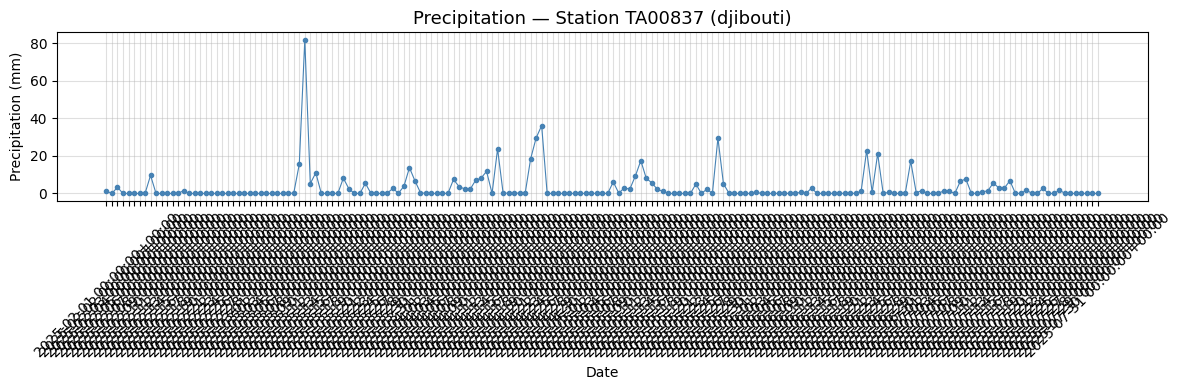

Station     : TA00837
Data range  : 0.00 mm – 81.74 mm
Records     : 181
Missing data: 0.0%


,TA00001,TA00020,TA00023,TA00024,TA00025_S000116,TA00025_S002904,TA00025_S002905,TA00030,TA00057,TA00066,...,TE00012,TE00013,TE00024,TE00026,TE00027,TE00028,TE00029,TE00043,TE00044,TE00066
2025-02-01 00:00:00+00:00,NaN,NaN,2.754,0.051,0.051,NaN,NaN,0.000,NaN,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-02 00:00:00+00:00,NaN,NaN,0.000,0.000,0.000,NaN,NaN,0.000,NaN,0.119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-03 00:00:00+00:00,NaN,NaN,0.000,0.034,0.000,NaN,NaN,0.000,NaN,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-04 00:00:00+00:00,NaN,NaN,0.000,0.034,0.000,NaN,NaN,0.000,NaN,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-05 00:00:00+00:00,NaN,NaN,0.000,0.051,0.000,NaN,NaN,0.000,NaN,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-27 00:00:00+00:00,0.119,0.017,NaN,NaN,NaN,0.0,0.0,0.000,0.0,0.051,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-28 00:00:00+00:00,0.017,0.000,NaN,NaN,NaN,0.0,0.0,0.136,0.0,0.034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29 00:00:00+00:00,0.000,0.000,NaN,NaN,NaN,0.0,0.0,0.000,0.0,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-30 00:00:00+00:00,0.000,0.000,NaN,NaN,NaN,0.0,0.0,0.000,0.0,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
# # @title ### 4a_2: Extracting TAHMO Precipitation data and preview
# # @markdown Using filter-stations to extract precipitation data <br>
# # @title ### 4a_1: Extract and visualise TAHMO data using filter stations

# # @markdown ❌ SKIP this step if you have your own data

# # save to the directory

# # print('Extracting Precipitation Data ...')
# region_precip = rd.multiple_measurements(stations_list=info['code'].tolist(),
#                                      startDate=start_date,
#                                      endDate=end_date,
#                                      variables=['pr'],
#                                          csv_file=f'{dir_path}/Ground_data')

# # check if the file exist to know if it was successful
# if not os.path.exists(f'{dir_path}/Ground_data.csv'):
#     print("❌ Precipitation data not extracted successfully.")
# else:
#     print("✅ Precipitation data extracted successfully.")

# # Visualise any random station data
# def plot_stations_data_randomly(eac_data):
#     import random
#     station_codes = eac_data.columns.to_list()
#     random_station = random.choice(station_codes)
#     station_data = eac_data[random_station]

#     plt.figure(figsize=(10, 5))
#     plt.plot(station_data.index, station_data.values, marker='o')
#     plt.title(f'Precipitation Data for Station {random_station}')
#     plt.xlabel('Date')

#     # Rotate date labels for better readability
#     plt.xticks(rotation=45)

#     plt.ylabel('Precipitation (mm)')
#     plt.grid(True)
#     plt.show()

#     print(f"Station Code: {random_station}")
#     print(f"Data Range: {station_data.min()} mm to {station_data.max()} mm")
#     print(f"Number of Records: {len(station_data)}")

# # plot_stations_data_randomly(region_precip)

# region_precip
# @title ### 4a_2: Extracting TAHMO Precipitation data and preview (robust version)
# @markdown Replaces original block — handles network drops, retries missing stations,
# @markdown and guarantees Ground_data.csv is saved to Drive before continuing.

import os, time, random
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────────────────────
MAX_RETRIES   = 3       # attempts per station on failure
RETRY_DELAY   = 10      # seconds to wait between retries
BATCH_SIZE    = 5       # stations per batch (reduces timeout risk)

stations_list = info['code'].tolist()
save_path     = f'{dir_path}/Ground_data.csv'

print(f"🌍 Region       : {region_query}")
print(f"📅 Date range   : {start_date} → {end_date}")
print(f"📡 Total stations: {len(stations_list)}")
print(f"💾 Save path    : {save_path}")
print("─" * 55)

# ── STEP 1: Check if file already exists (resume support) ────────────────────
existing_df      = pd.DataFrame()
already_fetched  = []

if os.path.exists(save_path):
    try:
        existing_df     = pd.read_csv(save_path, index_col=0)
        already_fetched = existing_df.columns.tolist()
        print(f"♻️  Resuming — {len(already_fetched)} stations already saved")
    except Exception:
        print("⚠️  Existing file unreadable — starting fresh")
        existing_df = pd.DataFrame()

# ── STEP 2: Determine which stations still need fetching ─────────────────────
pending  = [s for s in stations_list if s not in already_fetched]
failed   = []
all_data = [existing_df] if not existing_df.empty else []

print(f"⏳ Stations to fetch: {len(pending)}")
print("─" * 55)

# ── STEP 3: Fetch in batches with retry logic ─────────────────────────────────
batches = [pending[i:i+BATCH_SIZE] for i in range(0, len(pending), BATCH_SIZE)]

for b_idx, batch in enumerate(batches):
    print(f"\n📦 Batch {b_idx+1}/{len(batches)} — stations: {batch}")

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            result = rd.multiple_measurements(
                stations_list=batch,
                startDate=start_date,
                endDate=end_date,
                variables=['pr'],
            )

            if result is not None and not result.empty:
                all_data.append(result)

                # ── Save progress after every batch ──────────────────────
                combined_so_far = pd.concat(all_data, axis=1)
                combined_so_far = combined_so_far.loc[
                    :, ~combined_so_far.columns.duplicated()
                ]
                combined_so_far.to_csv(save_path)
                print(f"  ✅ Batch {b_idx+1} saved "
                      f"({combined_so_far.shape[1]} stations total so far)")
                break   # success — move to next batch
            else:
                print(f"  ⚠️  Attempt {attempt}: empty result returned")

        except Exception as e:
            print(f"  ❌ Attempt {attempt}/{MAX_RETRIES} failed: {e}")
            if attempt < MAX_RETRIES:
                print(f"  ⏱️  Waiting {RETRY_DELAY}s before retry...")
                time.sleep(RETRY_DELAY)
            else:
                print(f"  🚫 Giving up on batch {b_idx+1} — "
                      f"marking as failed: {batch}")
                failed.extend(batch)

# ── STEP 4: Build final DataFrame ────────────────────────────────────────────
if all_data:
    region_precip = pd.concat(all_data, axis=1)
    region_precip = region_precip.loc[
        :, ~region_precip.columns.duplicated()
    ]
    region_precip.to_csv(save_path)
else:
    region_precip = pd.DataFrame()

# ── STEP 5: Summary report ────────────────────────────────────────────────────
print("\n" + "═" * 55)
print(f"✅ EXTRACTION COMPLETE")
print(f"   Stations requested : {len(stations_list)}")
print(f"   Stations retrieved : {region_precip.shape[1] if not region_precip.empty else 0}")
print(f"   Stations failed    : {len(failed)}")
if failed:
    print(f"   Failed list        : {failed}")
print(f"   Date rows          : {region_precip.shape[0] if not region_precip.empty else 0}")
print(f"   Saved to           : {save_path}")
print(f"   File size          : "
      f"{os.path.getsize(save_path)/1024:.1f} KB"
      if os.path.exists(save_path) else "   ⚠️  File not found")
print("═" * 55)

# ── STEP 6: Visualise a random station ───────────────────────────────────────
def plot_stations_data_randomly(eac_data):
    if eac_data.empty:
        print("⚠️  No data to plot")
        return

    # pick a station that actually has data
    non_empty = [c for c in eac_data.columns
                 if eac_data[c].notna().sum() > 10]
    if not non_empty:
        print("⚠️  All stations are empty — nothing to plot")
        return

    random_station = random.choice(non_empty)
    station_data   = eac_data[random_station].dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(station_data.index, station_data.values,
             marker='o', markersize=3, linewidth=0.8, color='steelblue')
    plt.title(f'Precipitation — Station {random_station} ({region_query})',
              fontsize=13)
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    pct_missing = eac_data[random_station].isna().mean() * 100
    print(f"Station     : {random_station}")
    print(f"Data range  : {station_data.min():.2f} mm – {station_data.max():.2f} mm")
    print(f"Records     : {len(station_data)}")
    print(f"Missing data: {pct_missing:.1f}%")

plot_stations_data_randomly(region_precip)

# Display the full DataFrame for inspection
region_precip


In [63]:
# Step 1 — re-run the extraction but this time capture the returned object
print("Re-extracting precipitation data...")
region_precip = rd.multiple_measurements(
    stations_list=info['code'].tolist(),
    startDate=start_date,
    endDate=end_date,
    variables=['pr'],
    csv_file=f'{dir_path}/Ground_data'   # keep original param
)

# Step 2 — check what was actually returned
print(f"\nType returned: {type(region_precip)}")
print(f"Shape: {region_precip.shape if hasattr(region_precip, 'shape') else 'N/A'}")
print(f"Preview:\n{region_precip.head(3) if hasattr(region_precip, 'head') else region_precip}")

Re-extracting precipitation data...


Retrieving data for stations:   0%|          | 0/177 [00:00<?, ?it/s]


Type returned: <class 'pandas.core.frame.DataFrame'>
Shape: (181, 188)
Preview:
                           TA00001  TA00020  TA00023  TA00024  \
2025-02-01 00:00:00+00:00      NaN      NaN    2.754    0.051   
2025-02-02 00:00:00+00:00      NaN      NaN    0.000    0.000   
2025-02-03 00:00:00+00:00      NaN      NaN    0.000    0.034   

                           TA00025_S000116  TA00025_S002904  TA00025_S002905  \
2025-02-01 00:00:00+00:00            0.051              NaN              NaN   
2025-02-02 00:00:00+00:00            0.000              NaN              NaN   
2025-02-03 00:00:00+00:00            0.000              NaN              NaN   

                           TA00030  TA00057  TA00066  ...  TE00012  TE00013  \
2025-02-01 00:00:00+00:00      0.0      NaN    0.000  ...      NaN      NaN   
2025-02-02 00:00:00+00:00      0.0      NaN    0.119  ...      NaN      NaN   
2025-02-03 00:00:00+00:00      0.0      NaN    0.000  ...      NaN      NaN   

                    

In [64]:
import os

# Save the DataFrame manually to Drive
save_path = f'{dir_path}/Ground_data.csv'
region_precip.to_csv(save_path)

# Verify it actually landed
print(f"✅ Saved to: {save_path}")
print(f"   Size: {os.path.getsize(save_path)/1024:.1f} KB")
print(f"   Shape: {region_precip.shape}")
print(f"   Date range: {region_precip.index[0]} → {region_precip.index[-1]}")
print(f"   Stations: {region_precip.shape[1]}")

✅ Saved to: /content/drive/MyDrive/NOAA-workshop-data/Ground_data.csv
   Size: 167.3 KB
   Shape: (181, 188)
   Date range: 2025-02-01 00:00:00+00:00 → 2025-07-31 00:00:00+00:00
   Stations: 188


In [65]:
metadata_path = f'{dir_path}/Ground_Metadata.csv'

if os.path.exists(metadata_path):
    print(f"✅ Ground_Metadata.csv already exists")
    meta_preview = pd.read_csv(metadata_path)
    print(f"   Shape: {meta_preview.shape}")
    print(f"   Columns: {meta_preview.columns.tolist()}")
else:
    print("❌ Ground_Metadata.csv missing — saving now...")
    # 'info' is the station metadata DataFrame from the earlier step
    info.to_csv(metadata_path, index=False)
    print(f"✅ Saved Ground_Metadata.csv — {len(info)} stations")
    print(f"   Columns: {info.columns.tolist()}")

✅ Ground_Metadata.csv already exists
   Shape: (177, 29)
   Columns: ['Unnamed: 0', 'code', 'status', 'installationdate', 'elevationground', 'sensorinstallations', 'dataloggerinstallations', 'creatorid', 'created', 'updaterid', 'updated', 'location.id', 'location.name', 'location.type', 'location.timezone', 'location.timezoneoffset', 'location.address', 'location.city', 'location.state', 'location.countrycode', 'location.zipcode', 'location.latitude', 'location.longitude', 'location.elevationmsl', 'location.note', 'location.creatorid', 'location.created', 'location.updaterid', 'location.updated']


In [66]:
import subprocess

# Search the entire Colab filesystem for Ground_data.csv
print("Searching for Ground_data.csv ...")
result = subprocess.run(
    ['find', '/', '-name', 'Ground_data.csv', '-type', 'f'],
    capture_output=True, text=True, timeout=30
)
print(result.stdout if result.stdout else "❌ File not found anywhere")
print(result.stderr[:300] if result.stderr else "")

# Also check Drive mount status
print("\n── Drive mount check ──")
import os
print("Drive mounted:", os.path.exists('/content/drive/MyDrive'))
print("Workshop folder exists:", os.path.exists('/content/drive/MyDrive/NOAA-workshop-data'))

# List what IS in /content
print("\n── Contents of /content ──")
for item in os.listdir('/content'):
    print(" ", item)

Searching for Ground_data.csv ...
/content/drive/MyDrive/NOAA-workshop-data/Ground_data.csv

find: ‘/proc/65/task/65/net’: Invalid argument
find: ‘/proc/65/net’: Invalid argument


── Drive mount check ──
Drive mounted: True
Workshop folder exists: True

── Contents of /content ──
  .config
  config.json
  chirps_temp_Eritrea
  drive
  chirps_temp_Ethiopia
  sample_data


In [21]:
# @title ### 4b_1) Upload custom data {"display-mode":"form"}
# @markdown ❌ SKIP this step if you are using TAHMO data

# @markdown Please upload your Ground_Metadata.csv and Ground_data.csv files.

from google.colab import files
import pandas as pd
import os

dir_path = '/content/drive/MyDrive/NOAA-workshop-data'
os.makedirs(dir_path, exist_ok=True)

# check if the path was created successfully
if not os.path.exists(dir_path):
    print("❌ Path not created successfully.")
else:
    print("✅ Path created successfully.")

# Only proceed with custom data upload if Ground_data_source is set to 'custom'
if Ground_data_source.lower() == 'custom':
    # Delete existing files if they exist
    metadata_path = os.path.join(dir_path, 'Ground_Metadata.csv')
    data_path = os.path.join(dir_path, 'Ground_data.csv')

    if os.path.exists(metadata_path):
        os.remove(metadata_path)

    if os.path.exists(data_path):
        os.remove(data_path)

    # Change working directory to the target path
    os.chdir(dir_path)
    print(f"✅ Working directory set to: {os.getcwd()}")

    # Upload Ground_Metadata.csv
    print("\nPlease upload Ground_Metadata.csv:")
    uploaded_metadata = files.upload()
    if not uploaded_metadata:
        print("❌ No file uploaded for Ground_Metadata.csv")
        metadata_file_name = None
    else:
        metadata_file_name = list(uploaded_metadata.keys())[0]
        # Rename if needed
        if metadata_file_name != 'Ground_Metadata.csv':
            os.rename(metadata_file_name, 'Ground_Metadata.csv')
            metadata_file_name = 'Ground_Metadata.csv'
        print(f"✅ File saved as 'Ground_Metadata.csv'")


    # Upload Ground_data.csv
    print("\nPlease upload Ground_data.csv:")
    uploaded_data = files.upload()
    if not uploaded_data:
        print("❌ No file uploaded for Ground_data.csv.")
        data_file_name = None
    else:
        data_file_name = list(uploaded_data.keys())[0]
        # Rename if needed
        if data_file_name != 'Ground_data.csv':
            os.rename(data_file_name, 'Ground_data.csv')
            data_file_name = 'Ground_data.csv'
        print(f"✅ File saved as 'Ground_data.csv'")


    # --- Validation ---

    region_metadata = None
    region_precip_data = None

    # Validate Ground_Metadata.csv if uploaded
    if metadata_file_name:
        try:
            region_metadata = pd.read_csv(metadata_file_name)
            required_metadata_cols = ['Code', 'lat', 'lon']
            if not all(col in region_metadata.columns for col in required_metadata_cols):
                print(f"❌ Error: Ground_Metadata.csv must contain the columns: {required_metadata_cols}")
                region_metadata = None
            else:
                print("✅ Ground_Metadata.csv columns validated.")
                # Rename columns to match expected format later in the notebook
                region_metadata = region_metadata.rename(columns={'Code': 'code'})

        except Exception as e:
            print(f"❌ Error reading Ground_Metadata.csv: {e}")
            region_metadata = None

    # Validate Ground_data.csv if uploaded
    if data_file_name:
        try:
            region_precip_data = pd.read_csv(data_file_name)
            if 'Date' not in region_precip_data.columns:
                print("❌ Error: Ground_data.csv must contain a 'Date' column.")
                region_precip_data = None
            else:
                print("✅ Ground_data.csv 'Date' column validated.")

        except Exception as e:
            print(f"❌ Error reading Ground_data.csv: {e}")
            region_precip_data = None


    # Display number of stations if data is loaded
    if region_precip_data is not None:
        # Assuming all columns except 'Date' are stations
        station_columns = [col for col in region_precip_data.columns if col != 'Date']
        print(f"\nTotal number of stations in Ground_data.csv: {len(station_columns)}")
else:
    print(f"Skipping custom data upload as Ground_data_source is set to '{Ground_data_source}'.")


✅ Path created successfully.
✅ Working directory set to: /content/drive/MyDrive/NOAA-workshop-data

Please upload Ground_Metadata.csv:


❌ No file uploaded for Ground_Metadata.csv

Please upload Ground_data.csv:


❌ No file uploaded for Ground_data.csv.


In [ ]:
# @title ### 4b_2) Visualise and preview custom data {"display-mode":"form"}
# @markdown ❌ SKIP this step if you are using TAHMO data

# @markdown Please upload your Ground_Metadata.csv and Ground_data.csv files.

import plotly.express as px
import pandas as pd

def plot_stations_plotly(dataframes, colors=None, zoom=5, height=500,
                         width=900, legend_title='Station Locations'):
    """
    Plot stations from one or more dataframes on a Plotly mapbox.

    Each dataframe must have 'lat' and 'lon' columns.
    'colors' is a list specifying marker colors for each dataframe respectively.
    """
    if colors is None:
        colors = ["blue", "red", "green", "purple", "orange"]

    frames = []
    for i, df in enumerate(dataframes):
        temp = df.copy()
        temp["color"] = colors[i % len(colors)]  # cycle colors if more dfs than colors
        frames.append(temp)

    combined = pd.concat(frames, ignore_index=True)

    fig = px.scatter_mapbox(
        combined,
        lat="lat",
        lon="lon",
        color="color",
        hover_name="Code",
        zoom=zoom,
        height=height,
        width=width
    )

    fig.update_layout(
        mapbox_style="open-street-map",
        legend_title=legend_title,
        margin={"r": 0, "t": 30, "l": 0, "b": 0}
    )

    return fig

# Load the custom data files
try:
    region_metadata = pd.read_csv('/content/drive/MyDrive/NOAA-workshop-data/Ground_Metadata.csv')
    region_precip_data = pd.read_csv('/content/drive/MyDrive/NOAA-workshop-data/Ground_data.csv')

    # Display the first 5 rows of the ground data
    print("Preview of first 5 rows of Ground_data.csv:")
    display(region_precip_data.head())

    # Visualise the custom metadata
    print("\nVisualizing custom station locations:")

    # Check if metadata is loaded and has required columns and data
    if region_metadata is None or region_metadata.empty or not all(col in region_metadata.columns for col in ['lat', 'lon']):
        print("❌ Metadata not loaded correctly or is empty or missing 'lat' or 'lon' columns. Please check your Ground_Metadata.csv file.")
    elif region_metadata[['lat', 'lon']].isnull().any().any():
         print("❌ Metadata contains missing latitude or longitude values. Please check your Ground_Metadata.csv file.")
    else:
        fig = plot_stations_plotly([region_metadata], colors=["blue"])
        fig.show()


except FileNotFoundError:
    print("❌ Custom data files not found. Please upload Ground_Metadata.csv and Ground_data.csv")
except Exception as e:
    print(f"❌ An error occurred while processing custom data: {e}")

# **Step 5: Extract CHIRPS data**

In [67]:
# @title ### Extract the data from Google Earth engine project

# @markdown **Note**: For this workshop, we have done this process for you when we shared the Google Cloud invitation to the project

# --- 4. Convert downloaded tiffs to xarray ---

# import geemap
# import glob
# from tqdm.notebook import tqdm
#
# # Define region of interest (Kenya)
# roi = ee.Geometry.Polygon(region_geom)
#
# # --- 2. Set up CHIRPS collection ---
# collection_id = "UCSB-CHG/CHIRPS/PENTAD"
# chirps = ee.ImageCollection(collection_id).filterDate(start_date, end_date).select("precipitation")
# chirps = chirps.map(lambda img: img.clip(roi))
#
# export_dir = "chirps_temp"
# os.makedirs(export_dir, exist_ok=True)
#
# # Convert to Python list
# image_list = chirps.toList(chirps.size())
# n_images = image_list.size().getInfo()
#
# # --- 3. Download with progress bar ---
# pbar = tqdm(total=n_images, desc="Exporting CHIRPS", unit="file")
#
# for i in range(n_images):
#     img = ee.Image(image_list.get(i))
#     date_str = img.date().format("yyyyMMdd").getInfo()
#     out_file = os.path.join(export_dir, f"{date_str}.tif")
#
#     geemap.ee_export_image(
#         img,
#         filename=out_file,
#         scale=5500,
#         region=roi
#     )
#
#     pbar.update(1)
#     pbar.refresh()  # force redraw in Colab
#
# pbar.close()
#
# # --- 4. Convert downloaded tiffs to xarray ---
# tiff_files = sorted(glob.glob(os.path.join(export_dir, "*.tif")))
# ds = xr.open_mfdataset(tiff_files, combine="nested", concat_dim="time", engine="rasterio")
#
# dates = [os.path.basename(f).split(".")[0] for f in tiff_files]
# ds = ds.assign_coords(time=pd.to_datetime(dates, format="%Y%m%d"))
# ds = ds.squeeze("band", drop=True).rename({"band_data": "precipitation"})
# ds.rio.write_crs("EPSG:4326", inplace=True)
#
# # --- 5. Save as NetCDF ---
# export_path = f'{dir_path}/chirps_pentad_{region_query}.nc'
# ds.to_netcdf(export_path)
#
# # --- 6. Clean data (remove imputed values) ---
# chirps_ds = ds.where(ds != -9999)

# def open_nc(p):
#     try:
#         import xarray as xr
#         return xr.open_dataset(p) if os.path.exists(p) else None
#     except Exception as e: print('ℹ️ xarray error:', e); return None

# CHIRPS_NC=f'/content/drive/MyDrive/NOAA-workshop2/Datasets/{COUNTRY}/CHIRPS_2025-02-01_2025-07-31_{COUNTRY}.nc'

# chirps_ds = open_nc(CHIRPS_NC)


# print("✅ Chirps Data loaded successfully.")
# @title ### Extract the data from Google Earth Engine project

import os, glob
import xarray as xr
import pandas as pd
import ee

# ── Your GEE project ─────────────────────────────────────────────────────────
GEE_PROJECT = "natural-notch-435413-j3"

# ── Pre-made Drive path (TAHMO provided for Uganda / Kenya / Rwanda) ──────────
CHIRPS_NC = f'/content/drive/MyDrive/NOAA-workshop2/Datasets/{COUNTRY}/CHIRPS_2025-02-01_2025-07-31_{COUNTRY}.nc'

# ── Bounding boxes for countries you pull yourself [lon_min, lat_min, lon_max, lat_max]
COUNTRY_BBOX = {
    "Ethiopia":  [33.0,  3.0,  48.0, 15.0],
    "Tanzania":  [29.0, -12.0, 41.0, -1.0],
    "Eritrea":   [36.5, 12.5,  43.5, 18.0],
    "Djibouti":  [41.5, 10.9,  43.5, 12.7],
    # ← add future countries here, same format
}

def open_nc(p):
    try:
        return xr.open_dataset(p) if os.path.exists(p) else None
    except Exception as e:
        print(f'ℹ️ xarray error: {e}')
        return None

# ── 1. Try the pre-made Drive file first ─────────────────────────────────────
chirps_ds = open_nc(CHIRPS_NC)

if chirps_ds is not None:
    print(f"✅ CHIRPS loaded from Drive: {CHIRPS_NC}")

# ── 2. If missing, pull from GEE and save back to Drive ──────────────────────
else:
    print(f"⚠️  No pre-made file for '{COUNTRY}' — pulling from GEE...")

    # Initialise EE with project
    try:
        ee.Initialize(project=GEE_PROJECT)
        print(f"✅ Earth Engine initialised (project: {GEE_PROJECT})")
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=GEE_PROJECT)
        print(f"✅ Earth Engine authenticated and initialised (project: {GEE_PROJECT})")

    # Resolve bounding box
    if COUNTRY in COUNTRY_BBOX:
        roi = ee.Geometry.Rectangle(COUNTRY_BBOX[COUNTRY])
        print(f"   Bbox: {COUNTRY_BBOX[COUNTRY]}")
    elif 'region_geom' in locals() and region_geom:
        roi = ee.Geometry.Polygon(region_geom)
        print(f"   Using region_geom from Step 3")
    else:
        raise ValueError(
            f"No bounding box for '{COUNTRY}'. "
            f"Add it to COUNTRY_BBOX above, or set region_geom in Step 3."
        )

    # Pull CHIRPS pentad collection
    chirps_col = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterDate(start_date, end_date)
        .filterBounds(roi)
        .select("precipitation")
        .map(lambda img: img.clip(roi))
    )
    n = chirps_col.size().getInfo()
    print(f"   {n} pentad images found ({start_date} → {end_date})")

    # Install geemap if needed
    try:
        import geemap
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "geemap", "-q"], check=True)
        import geemap

    from tqdm.notebook import tqdm

    # Download each pentad as a GeoTIFF (skips files already on disk)
    export_dir = f'/content/chirps_temp_{COUNTRY}'
    os.makedirs(export_dir, exist_ok=True)
    image_list = chirps_col.toList(n)

    for i in tqdm(range(n), desc=f"Exporting CHIRPS ({COUNTRY})", unit="file"):
        img      = ee.Image(image_list.get(i))
        date_str = img.date().format("yyyyMMdd").getInfo()
        out_file = os.path.join(export_dir, f"{date_str}.tif")
        if os.path.exists(out_file):
            continue
        geemap.ee_export_image(img, filename=out_file, scale=5500,
                               region=roi, file_per_band=False)

    # Assemble TIFFs → xarray
    tiff_files = sorted(glob.glob(os.path.join(export_dir, "*.tif")))
    print(f"   Converting {len(tiff_files)} TIFFs → NetCDF...")

    ds    = xr.open_mfdataset(tiff_files, combine="nested",
                              concat_dim="time", engine="rasterio")
    dates = [os.path.basename(f).split(".")[0] for f in tiff_files]
    ds    = ds.assign_coords(time=pd.to_datetime(dates, format="%Y%m%d"))
    ds    = ds.squeeze("band", drop=True).rename({"band_data": "precipitation"})
    ds.rio.write_crs("EPSG:4326", inplace=True)
    chirps_ds = ds.where(ds != -9999)

    # Save to Drive — next run will load instantly via open_nc above
    os.makedirs(os.path.dirname(CHIRPS_NC), exist_ok=True)
    chirps_ds.to_netcdf(CHIRPS_NC)
    print(f"   ✅ Saved to Drive: {CHIRPS_NC}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✅ CHIRPS ready for '{COUNTRY}'")
print(f"   Dimensions : {dict(chirps_ds.dims)}")
print(f"   Variables  : {list(chirps_ds.data_vars)}")
print(f"   Time range : {chirps_ds.time.values[0]} → {chirps_ds.time.values[-1]}")


⚠️  No pre-made file for 'Tanzania' — pulling from GEE...
✅ Earth Engine initialised (project: natural-notch-435413-j3)
   Bbox: [29.0, -12.0, 41.0, -1.0]
   36 pentad images found (2025-02-01 → 2025-07-31)


Exporting CHIRPS (Tanzania):   0%|          | 0/36 [00:00<?, ?file/s]

Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250201.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250206.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250211.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250216.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250221.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250226.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250301.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250306.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250311.tif
Generating URL ...
Please wait ...
Data downloaded to /content/chirps_temp_Tanzania/20250316.tif
Generating URL ...
Please wait

# **Step 6: Visualise data availability for ground stations and handle missing data**


In [68]:
# @title ### 6a) Load the extracted CHIRPS and Ground Precipitation and Metadata

# from scipy.stats import pearsonr, ttest_rel
# handle runtime disconnected issues to begin from this step
# 1. check if region query is defined
if not 'region_query' in locals():
    region_query = input("🌍 It seems the runtime was disconnected please enter the region you had selected again: ")
    print('Re-Installing required dependencies ...')
    !pip install git+https://github.com/TAHMO/NOAA.git > /dev/null 2>&1
    import xarray as xr
    import time
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import os
    # import ee
    import numpy as np
    # check if config.json file is already available
    if not os.path.exists('/content/config.json'):
      from google.colab import files
      # Upload the TAHMO config file
      print('Please upload the config file provided ...')
      uploaded = files.upload()

    # load the config.json file
    with open('/content/config.json', 'r') as f:
        config = json.load(f)

    location_key = config['location_keys']  # Google Maps API key
    api_key = config['apiKey']
    api_secret = config['apiSecret']


    time.sleep(2)
    # region_query = input("🌍 It seems the runtime was disconnected please write your region you had put againe: ")
    # print(f"Selected: {region_query}")
    # region_query = region_query.lower()

    # re importing the modules


    # import os
    # os.chdir('NOAA-workshop')


    from utils.ground_stations import plot_stations_folium
    from utils.helpers import get_region_geojson
    from utils.CHIRPS_helpers import get_chirps_pentad_gee
    from utils.plotting import plot_xarray_data, plot_xarray_data2
    from utils.filter_stations import RetrieveData

    from google.colab import drive

    def xmin_ymin_xmax_ymax(polygon):
      lons = [pt[0] for pt in polygon]
      lats = [pt[1] for pt in polygon]
      return min(lons), min(lats), max(lons), max(lats)

    def fetch_region(query):
      """Fetch polygon geometry and bounding box for region name"""
      region_geom = get_region_geojson(query, location_key)['geometry']['coordinates'][0]
      xmin, ymin, xmax, ymax = xmin_ymin_xmax_ymax(region_geom)
      print(f"✅ Selected: {query}")
      print(f"Bounding box -> xmin: {xmin}, ymin: {ymin}, xmax: {xmax}, ymax: {ymax}")
      return region_geom, (xmin, ymin, xmax, ymax)

    # remounting drive
    drive.mount('/content/drive', force_remount=True)
    # check if the drve folder is available in /content/drive
    if not os.path.exists('/content/drive/MyDrive/NOAA-workshop-data'):
      print("❌ Google Drive not mounted successfully.")
    else:
      print("✅ Google Drive mounted successfully.")

    rd = RetrieveData(api_key,
                    api_secret)

    region_geom, bbox = fetch_region(region_query)

    xmin, ymin, xmax, ymax = xmin_ymin_xmax_ymax(region_geom)

    dir_path = '/content/drive/MyDrive/NOAA-workshop-data'

    # check if the metadata, chirps and precip data is available
    if not os.path.exists(f'{dir_path}/tahmo_precip_{region_query}.csv'):
      print("❌ Precipitation data not extracted successfully.")
    else:
      print("✅ Precipitation data extracted successfully.")

    if not os.path.exists(f'{dir_path}/tahmo_metadata_{region_query}.csv'):
      print("❌ Metadata not extracted successfully.")
    else:
      print("✅ Metadata extracted successfully.")

    if not os.path.exists(f'{dir_path}/chirps_pentad_{region_query}.nc'):
      print("❌ CHIRPS data not extracted successfully.")
    else:
      print("✅ CHIRPS data extracted successfully.")

import xarray as xr
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
import ee
import xarray as xr
import numpy as np



region_precip_data = pd.read_csv(f'{dir_path}/Ground_data.csv')
# eac metadata
region_metadata = pd.read_csv(f"{dir_path}/Ground_Metadata.csv")
if Ground_data_source.lower() == 'tahmo':
  region_metadata = region_metadata[['code', 'location.latitude', 'location.longitude']].rename(columns={'location.latitude': 'lat', 'location.longitude': 'lon'})
elif Ground_data_source.lower() == 'custom':
  region_metadata = region_metadata.rename(columns={'Code': 'code'})
  region_metadata = region_metadata[['code', 'lat', 'lon']]
  # Rename the date column for consistency
  region_precip_data = region_precip_data.rename(columns={"Date": "Unnamed: 0"})

# Format the TAHMO data
region_precip_data = region_precip_data.rename(columns={"Unnamed: 0": "Date"})
region_precip_data['Date'] = pd.to_datetime(region_precip_data['Date'], format='mixed', dayfirst=True)
region_precip_data = region_precip_data.set_index('Date')
region_precip_data.index = region_precip_data.index.tz_localize(None)
multiple_sensors = [i for i in region_precip_data.columns if len(i.split('_')) > 1]
region_precip_data = region_precip_data.drop(columns=multiple_sensors)
# region_precip_data = region_precip_data.dropna(how='all', axis=1)

print("✅ Step successful.")

✅ Step successful.


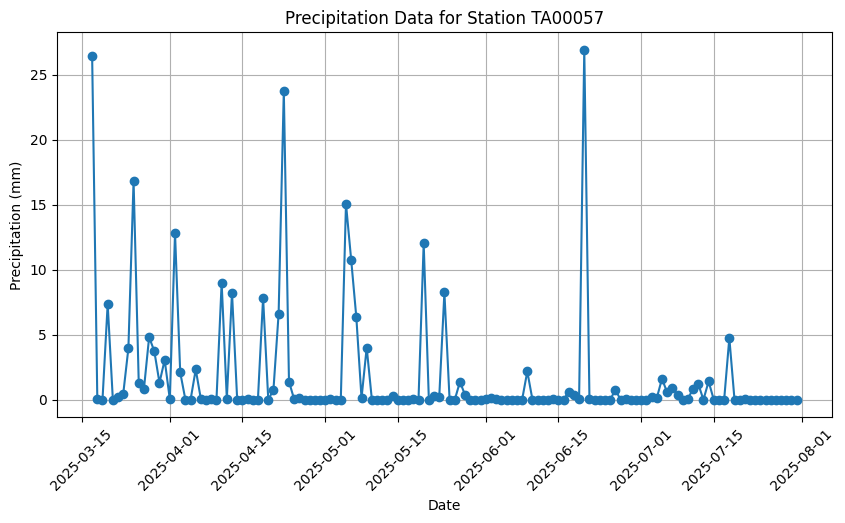

Station Code: TA00057
Data Range: 0.0 mm to 26.914 mm
Number of Records: 181


In [69]:
# @title ### 6b) Check the range of the data and plot any of the stations randomly
# @markdown Rerun this cell to visualise the next random station in the region <br>
def plot_stations_data_randomly(eac_data):
    import random
    station_codes = eac_data.columns.to_list()
    random_station = random.choice(station_codes)
    station_data = eac_data[random_station]

    plt.figure(figsize=(10, 5))
    plt.plot(station_data.index, station_data.values, marker='o')
    plt.title(f'Precipitation Data for Station {random_station}')
    plt.xlabel('Date')

    # Rotate date labels for better readability
    plt.xticks(rotation=45)

    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.show()

    print(f"Station Code: {random_station}")
    print(f"Data Range: {station_data.min()} mm to {station_data.max()} mm")
    print(f"Number of Records: {len(station_data)}")

plot_stations_data_randomly(region_precip_data)

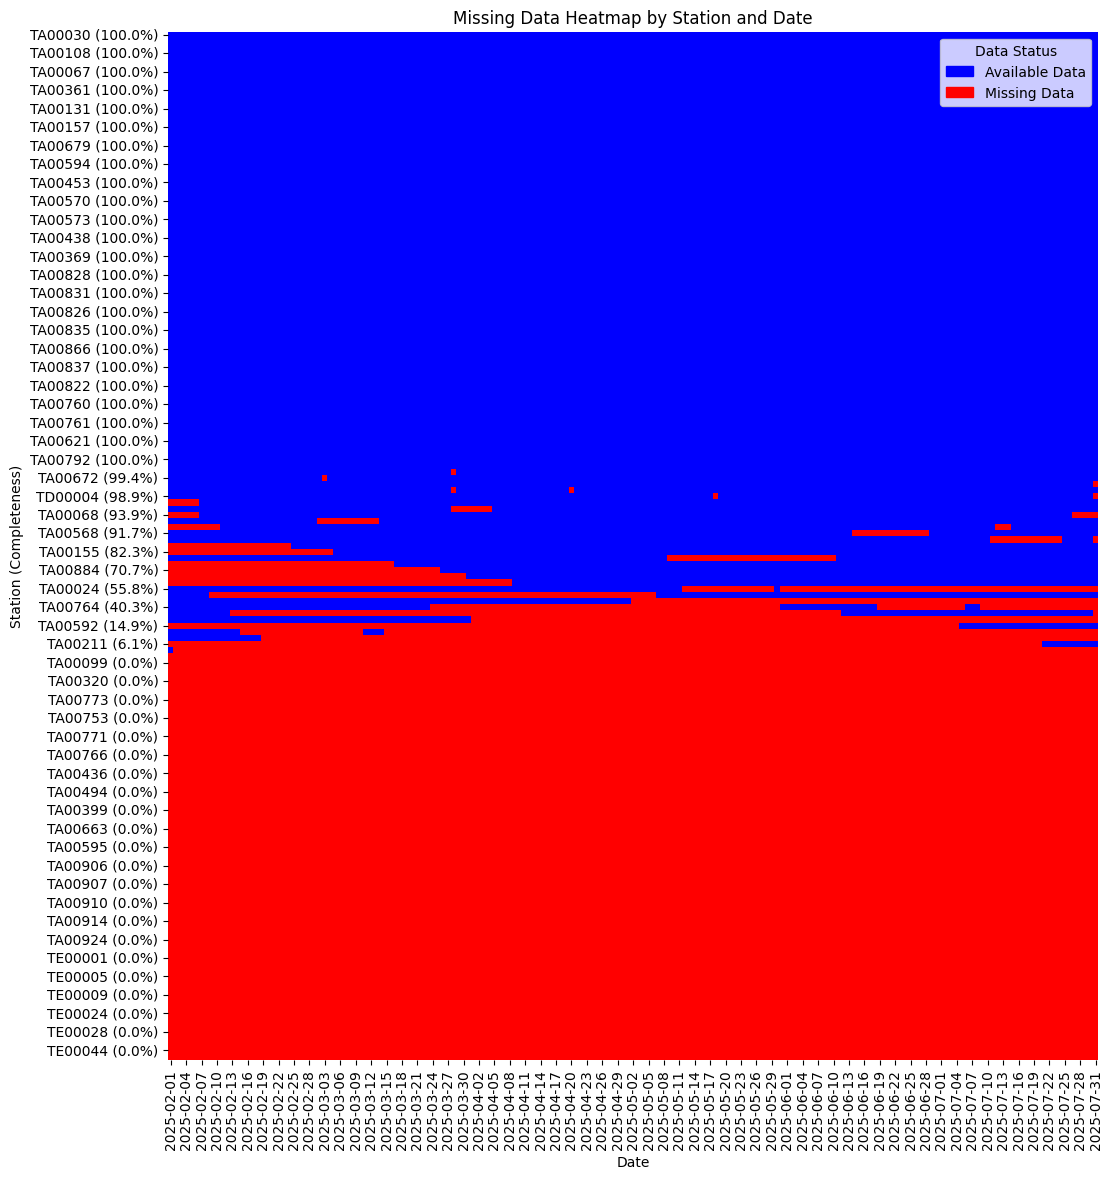

In [70]:
# @title ### 6c) Visualise missing data for each station {"display-mode":"form"}
# @markdown The generated chart shows the available data on y axis and a heatmap of available
# Get the stations with missing data
# missing_stations = region_precip_data.columns[region_precip_data.isna().any()].tolist()
# # print(f"Stations with missing data: {missing_stations}")
# # drop stations with all missing data
# region_precip_data = region_precip_data.dropna(how='all', axis=1)
# region_precip_data.isna().sum().sort_values().plot(kind='bar', title='Missing Data Count per Variable', figsize=(40, 10))
# # Get the stations with missing data
# missing_stations = region_precip_data.columns[region_precip_data.isna().any()].tolist()
# print(f"Stations with missing data: {missing_stations}")
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.patches as mpatches

# Drop stations with multiple sensors station_sensor columns
multiple_sensors = [i for i in region_precip_data.columns if len(i.split('_')) > 1]
region_precip_data_filtered = region_precip_data.drop(columns=multiple_sensors)

# Calculate missing data percentage per station over time
missing_data = region_precip_data_filtered.isnull().T
missing_data.columns = list(missing_data.columns.tz_localize(None).astype(str))

# Calculate overall completeness percentage for each station
overall_completeness = (1 - region_precip_data_filtered.isnull().mean(axis=0)) * 100

# Sort stations by overall completeness in descending order
sorted_stations = overall_completeness.sort_values(ascending=False).index
missing_data_sorted = missing_data.loc[sorted_stations]

# Determine the number of stations to dynamically adjust height
num_stations = len(missing_data_sorted)
# Define a base height and an additional height per station
base_height = 5  # Base height in inches
height_per_station = 0.05 # Additional height per station in inches
fig_height = base_height + num_stations * height_per_station

# Create a custom colormap: Blue for non-missing (False), Red for missing (True)
cmap = matplotlib.colors.ListedColormap(['blue', 'red'])

plt.figure(figsize=(12, fig_height))
# Use the custom colormap and specify levels for the two colors, and remove the legend
sns.heatmap(missing_data_sorted, cbar=False, cmap=cmap, vmin=0, vmax=1)

# Create legend patches
blue_patch = mpatches.Patch(color='blue', label='Available Data')
red_patch = mpatches.Patch(color='red', label='Missing Data')

# Add legend to the plot
plt.legend(handles=[blue_patch, red_patch], title="Data Status", loc='upper right')

# Update y-axis labels to include completeness percentage
ax = plt.gca()
y_labels = [f"{label.get_text()} ({overall_completeness.loc[label.get_text()]:.1f}%)" for label in ax.get_yticklabels()]
ax.set_yticklabels(y_labels)

plt.title('Missing Data Heatmap by Station and Date')
plt.xlabel('Date')
plt.ylabel('Station (Completeness)')
plt.xticks(rotation=90) # Rotate x-axis labels
plt.show()

# **Step 7: Aggregate the Ground data to Pentads**

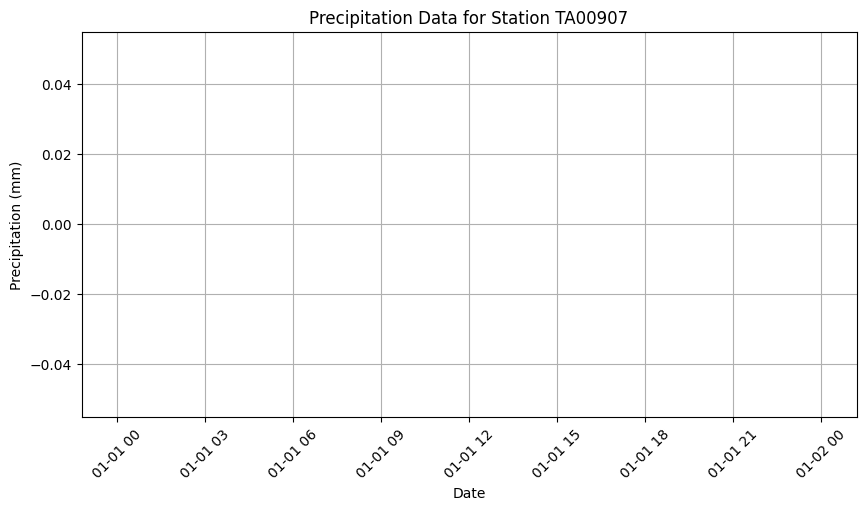

Station Code: TA00907
Data Range: nan mm to nan mm
Number of Records: 36


In [71]:
# @title Aggregate station rain to pentads to match CHIRPS. {"display-mode":"form"}
# @markdown In order to match CHIRPS and how it is extracted we will aggregate the data to pentads (5 days)
region_precip_pentad = rd.aggregate_variables(region_precip_data, freq='5D', method='sum')[:-1]
plot_stations_data_randomly(region_precip_pentad)


In [72]:
# Alternative fix — monkey-patch the missing import
# Run this cell before Step 8, no restart needed

import xarray as xr
import xarray.core.nanops as _nanops
import sys

# Inject nanops back into the path the notebook expects
if not hasattr(xr, 'computation'):
    import types
    xr.computation = types.ModuleType('xarray.computation')

sys.modules['xarray.computation.nanops'] = _nanops
sys.modules['xarray.nanops'] = _nanops

print("✅ xarray nanops patch applied — re-run Step 8 now")

✅ xarray nanops patch applied — re-run Step 8 now


# **Step 8: Build CHIRPS Nearest data for the ground stations**

In [73]:
# @title At this step we are building the station dataset by using the station metadata (latitude and longitude) to get the nearest value for CHIRPS {"display-mode":"form"}

import numpy as np
import pandas as pd

# Define a function to build station datasets from any grid dataset
def build_station_dataset_from_grid(grid_ds, stations_metadata, k=NEIGHBORHOOD):
    """
    Build station dataset by sampling grid values at station locations.

    Parameters
    ----------
    grid_ds : xarray.Dataset
        Grid dataset with precipitation data. Assumes time, lat, lon dimensions.
    stations_metadata : pd.DataFrame
        Must contain columns ['code', 'location.latitude', 'location.longitude']
    k : int, optional
        Number of nearest grid points to average. Default is 1 (just nearest pixel).
    """
    if grid_ds is None:
        return None

    import numpy as np
    import pandas as pd

    all_stations_data = {}

    # Check for 'lat'/'lon' or 'y'/'x' dimensions
    if 'lat' in grid_ds.coords and 'lon' in grid_ds.coords:
        grid_lats = grid_ds['lat'].values
        grid_lons = grid_ds['lon'].values
        lat_dim, lon_dim = 'lat', 'lon'
    elif 'y' in grid_ds.coords and 'x' in grid_ds.coords:
        grid_lats = grid_ds['y'].values
        grid_lons = grid_ds['x'].values
        lat_dim, lon_dim = 'y', 'x'
    else:
        print(f"⚠️ Could not find 'lat'/'lon' or 'y'/'x' dimensions in dataset.")
        return None

    # Find the precipitation variable name
    precip_var = None
    for var in grid_ds.data_vars:
        # Look for common precipitation variable names and dimensions
        if 'precip' in var.lower() or 'rainfall' in var.lower() or 'precipitation' in var.lower() or 'rfe' in var.lower():
             if (lat_dim in grid_ds[var].dims and lon_dim in grid_ds[var].dims and 'time' in grid_ds[var].dims):
                 precip_var = var
                 break

    if precip_var is None:
        print(f"⚠️ Could not find a precipitation variable in the dataset.")
        return None


    for _, row in stations_metadata.iterrows():
        station_code = row['code']
        # Access lat and lon using the correct column names from the metadata
        lat = row['lat']
        lon = row['lon']

        # Find the nearest grid point(s)
        # This is a simplified approach, more accurate methods might be needed for complex grids
        lat_idx = np.abs(grid_lats - lat).argmin()
        lon_idx = np.abs(grid_lons - lon).argmin()

        if k == 1:
            # Extract data for the single nearest pixel
            station_da = grid_ds[precip_var].isel({lat_dim: lat_idx, lon_dim: lon_idx})
        else:
            # Extract data for k nearest points and compute mean
            # This is a basic implementation, a more sophisticated approach might involve distance weighting
            lat_slice = slice(max(lat_idx - k // 2, 0), min(lat_idx + k // 2 + 1, len(grid_lats)))
            lon_slice = slice(max(lon_idx - k // 2, 0), min(lon_idx + k // 2 + 1, len(grid_lons)))

            sub = grid_ds[precip_var].isel({lat_dim: lat_slice, lon_dim: lon_slice})

            # Handle potential empty slices if k is too large near edges
            if sub[lat_dim].size == 0 or sub[lon_dim].size == 0:
                 print(f"⚠️ Skipping station {station_code}: Could not extract data for {k} nearest points near grid edge.")
                 all_stations_data[station_code] = pd.Series(dtype=float) # Add an empty series for this station
                 continue


            station_da = sub.mean(dim=[lat_dim, lon_dim], skipna=True)


        # Convert xarray DataArray to pandas Series and rename
        try:
            station_series = station_da.to_series()
            station_series.name = station_code
            all_stations_data[station_code] = station_series
        except Exception as e:
             print(f"Error converting xarray to series for station {station_code}: {e}")
             all_stations_data[station_code] = pd.Series(dtype=float) # Add an empty series in case of error


    # Combine all station series into a single DataFrame
    # Use concat with join='outer' to handle potential missing dates in individual series
    combined_df = pd.concat(all_stations_data.values(), axis=1, keys=all_stations_data.keys())
    return combined_df

# Assuming df_meta is available from previous steps

if 'region_metadata' not in locals() or region_metadata.empty:
    metadata_csv = './tahmo_metadata.csv' # Assuming this is the path to the metadata file
    if os.path.exists(metadata_csv):
        region_metadata = pd.read_csv(metadata_csv)
        print("Reloaded ground truth metadata.")
    else:
        print(f"⚠️ Ground metadata CSV not found at {metadata_csv}. Cannot extract daily station data from satellite products.")
        region_metadata = pd.DataFrame() # Set to empty DataFrame to prevent errors

if 'chirps_ds' not in locals() or chirps_ds is None:
    print("⚠️ CHIRPS dataset (ds_chirps) not loaded. Cannot build station data.")
    chirps_station_df = pd.DataFrame() # Set to empty DataFrame
else:
    if not region_metadata.empty:
        # Use all available stations in region_metadata
        available_stations_meta = region_metadata.copy()

        if not available_stations_meta.empty:
            print("Extracting daily data for all stations from CHIRPS...")
            # Use the build_station_dataset_from_grid function to extract CHIRPS data
            # Make sure to pass the correct metadata with 'lat' and 'lon'
            # Assuming 'build_station_dataset_from_grid' function exists and is correctly imported/defined elsewhere
            # and it expects a DataFrame with 'code', 'lat', and 'lon' columns.
            # If the function requires 'location.latitude' and 'location.longitude', adjust the column names here.
            try:
                # Check if the required function exists in the environment
                if 'build_station_dataset_from_grid' in globals():
                    # Filter chirps_ds by start_date and end_date before passing it to the function
                    chirps_ds_filtered = chirps_ds.sel(time=slice(start_date, end_date))

                    chirps_station_df = build_station_dataset_from_grid(chirps_ds_filtered, available_stations_meta, k=NEIGHBORHOOD)

                    if chirps_station_df is not None and not chirps_station_df.empty:
                        print("✅ Daily station data extracted for CHIRPS.")
                        print("\nHead of CHIRPS daily station data:")
                        display(chirps_station_df.head()) # Display the head of the extracted data
                    else:
                        print("⚠️ No daily station data extracted for CHIRPS. The extraction function might have returned None or an empty DataFrame.")
                        chirps_station_df = pd.DataFrame() # Ensure it's a DataFrame if extraction failed
                else:
                    print("❌ Error: The 'build_station_dataset_from_grid' function is not defined.")
                    chirps_station_df = pd.DataFrame() # Set to empty DataFrame if function is missing

            except Exception as e:
                print(f"❌ An error occurred during CHIRPS data extraction: {e}")
                chirps_station_df = pd.DataFrame() # Set to empty DataFrame on error

        else:
            print("⚠️ Station metadata is empty. Cannot extract daily station data from CHIRPS.")
            chirps_station_df = pd.DataFrame() # Set to empty DataFrame
    else:
        print("⚠️ Ground data or metadata not loaded or is empty. Cannot extract daily station data from CHIRPS.")
        chirps_station_df = pd.DataFrame() # Set to empty DataFrame

# Now, if chirps_station_df is not empty, display it in a table
if not chirps_station_df.empty:
    print("\nCHIRPS daily station data table:")
    display(chirps_station_df)
else:
    print("\nNo CHIRPS daily station data available to display in a table.")

Extracting daily data for all stations from CHIRPS...
✅ Daily station data extracted for CHIRPS.

Head of CHIRPS daily station data:


,TA00001,TA00020,TA00023,TA00024,TA00025,TA00030,TA00057,TA00066,TA00067,TA00068,...,TE00012,TE00013,TE00024,TE00026,TE00027,TE00028,TE00029,TE00043,TE00044,TE00066
time,,,,,,,,,,,,,,,,,,,,,
2025-02-01,6.765026,1.090350,0.434661,0.888960,1.404618,4.252749,1.187750,1.623323,0.774766,0.579080,...,1.118513,1.031986,11.974191,2.716345,5.168528,4.252749,4.252749,0.597044,0.424057,0.887711
2025-02-06,6.140485,0.925779,0.515119,0.624782,0.841147,1.906845,0.764781,0.975354,0.899568,0.598795,...,0.540450,0.682600,4.625239,1.511894,1.740262,1.906845,1.906845,0.502654,0.535078,0.846210
2025-02-11,5.132720,0.966182,0.625266,0.643348,0.828746,3.344164,0.782103,0.967303,0.986203,0.618438,...,0.618957,0.703050,5.709635,1.522077,1.843507,3.344164,3.344164,0.540996,0.666656,0.886326
2025-02-16,1.251797,1.036096,0.525307,0.682240,0.868423,2.003211,0.839841,1.034303,0.995202,0.717253,...,0.640700,0.737559,1.622090,1.648585,1.723789,2.003211,2.003211,0.628267,0.559882,0.899591
2025-02-21,0.921680,1.097116,0.553362,0.781366,0.977909,2.037462,0.922300,1.163961,1.020262,1.021511,...,0.781114,0.852621,1.021320,1.759665,1.785789,2.037462,2.037462,0.754718,0.583576,0.922177



CHIRPS daily station data table:


,TA00001,TA00020,TA00023,TA00024,TA00025,TA00030,TA00057,TA00066,TA00067,TA00068,...,TE00012,TE00013,TE00024,TE00026,TE00027,TE00028,TE00029,TE00043,TE00044,TE00066
time,,,,,,,,,,,,,,,,,,,,,
2025-02-01,6.765026,1.090350,0.434661,0.888960,1.404618,4.252749,1.187750,1.623323,0.774766,0.579080,...,1.118513,1.031986,11.974191,2.716345,5.168528,4.252749,4.252749,0.597044,0.424057,0.887711
2025-02-06,6.140485,0.925779,0.515119,0.624782,0.841147,1.906845,0.764781,0.975354,0.899568,0.598795,...,0.540450,0.682600,4.625239,1.511894,1.740262,1.906845,1.906845,0.502654,0.535078,0.846210
2025-02-11,5.132720,0.966182,0.625266,0.643348,0.828746,3.344164,0.782103,0.967303,0.986203,0.618438,...,0.618957,0.703050,5.709635,1.522077,1.843507,3.344164,3.344164,0.540996,0.666656,0.886326
2025-02-16,1.251797,1.036096,0.525307,0.682240,0.868423,2.003211,0.839841,1.034303,0.995202,0.717253,...,0.640700,0.737559,1.622090,1.648585,1.723789,2.003211,2.003211,0.628267,0.559882,0.899591
2025-02-21,0.921680,1.097116,0.553362,0.781366,0.977909,2.037462,0.922300,1.163961,1.020262,1.021511,...,0.781114,0.852621,1.021320,1.759665,1.785789,2.037462,2.037462,0.754718,0.583576,0.922177
2025-02-26,0.458975,0.671624,0.403355,0.337019,0.616658,1.174947,0.574691,0.728058,0.371369,0.501691,...,0.604072,0.493517,0.518659,1.020575,1.094111,1.174947,1.174947,0.573688,0.424741,0.547867
2025-03-01,2.048714,3.706877,1.778625,4.250927,3.063212,2.665841,3.478556,3.120670,2.961425,2.160414,...,2.981824,3.737136,2.118770,3.676708,2.492436,2.665841,2.665841,1.648942,1.395694,3.714402
2025-03-06,17.486158,45.588570,14.986387,39.570332,60.134792,39.929504,57.811794,62.543987,11.894398,8.371389,...,13.073165,44.969402,23.039078,67.547333,41.906746,39.929504,39.929504,12.614172,14.225979,35.501797
2025-03-11,27.502554,24.232582,12.620865,19.194828,14.548181,25.885798,14.973692,14.874905,33.026619,28.584633,...,6.890048,15.013148,30.532812,18.880043,25.245047,25.885798,25.885798,10.954167,8.717827,16.205204


# **Step 9: Visualise CHIRPS vs the Ground stations**

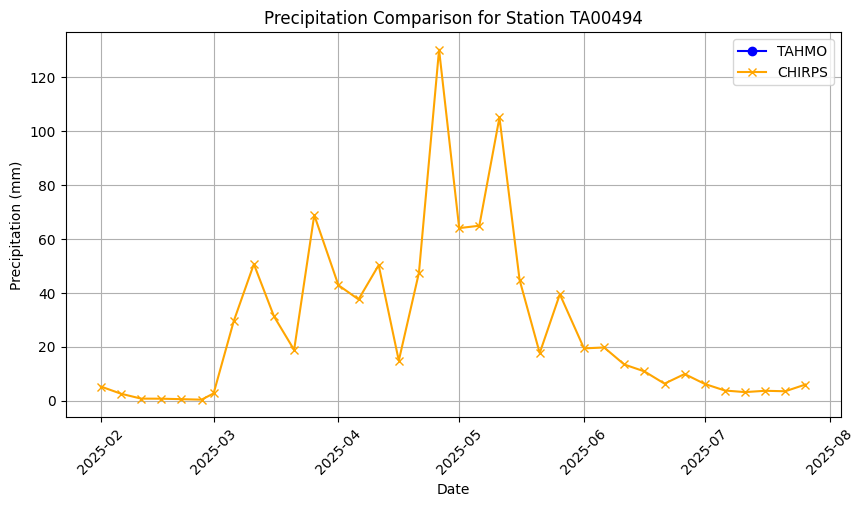

Station Code: TA00494
TAHMO Data Range: nan mm to nan mm
CHIRPS Data Range: 0.39283832907676697 mm to 130.2283935546875 mm
Number of TAHMO Records: 36
Number of CHIRPS Records: 36


In [74]:
# @title ### Plot the CHIRPS data and TAHMO equivalents for a random station
# @markdown Every single time we run this cell we get to visualise the CHIRPS v Ground data comparison for a different station within the region
chirps_stations = chirps_station_df
def plot_chirps_vs_tahmo_randomly(eac_pentad, chirps_stations, station_code=None):
    if station_code is None:
      import random
      station_codes = eac_pentad.columns.intersection(chirps_stations.columns).tolist()
      if not station_codes:
          print("No common stations between EAC pentad data and CHIRPS data.")
          return

      random_station = random.choice(station_codes)
    else:
      random_station = station_code

    tahmo_data = eac_pentad[random_station]
    chirps_data = chirps_stations[random_station]

    plt.figure(figsize=(10, 5))
    plt.plot(tahmo_data.index, tahmo_data.values, marker='o', label='TAHMO', color='blue')
    plt.plot(chirps_data.index, chirps_data.values, marker='x', label='CHIRPS', color='orange')
    plt.title(f'Precipitation Comparison for Station {random_station}')
    plt.xlabel('Date')

    # Rotate date labels for better readability
    plt.xticks(rotation=45)

    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Station Code: {random_station}")
    print(f"TAHMO Data Range: {tahmo_data.min()} mm to {tahmo_data.max()} mm")
    print(f"CHIRPS Data Range: {chirps_data.min()} mm to {chirps_data.max()} mm")
    print(f"Number of TAHMO Records: {len(tahmo_data)}")
    print(f"Number of CHIRPS Records: {len(chirps_data)}")

plot_chirps_vs_tahmo_randomly(region_precip_pentad, chirps_stations)

# **Step 10: Compute station confidence scores**

In [75]:
# @title ### 10a) Run this cell to compute station scores
# @title Confidence Score Formula
# @markdown ### **Confidence Score Formula**
# @markdown For each station, the confidence score is computed as:
# @markdown
# @markdown $$
# @markdown \text{Confidence Score} = 100 \times \big(0.1 \cdot C \;+\; 0.5 \cdot r \;+\; 0.1 \cdot (1 - O) \;+\; 0.3 \cdot(1- b) \big)
# @markdown $$
# @markdown
# @markdown Where:
# @markdown - $C = 1 -$ (missing fraction of observations), i.e. **completeness**
# @markdown - $r =$ Spearman correlation coefficient between observed and CHIRPS pentads
# @markdown - $O =$ fraction of outliers (observed values < 0)
# @markdown - $b =$ Bias Significance - paired $t$-test between observed and simulated values (significant if $p < 0.05$)
# @markdown
# @markdown ---
# @markdown
# @markdown **Additional metrics per station:**
# @markdown
# @markdown - **RMSE**
# @markdown $$
# @markdown \text{RMSE} = \sqrt{\frac{1}{n} \sum (obs - sim)^2}
# @markdown $$
# @markdown
# @markdown - **Adjusted confidence score**
# @markdown $$
# @markdown \text{Adjusted Confidence Score} = \text{Confidence Score} - \text{RMSE}
# @markdown $$
# @markdown

from scipy.stats import pearsonr, ttest_rel
# spearman correlation
from scipy.stats import spearmanr

def compute_station_scores(eac_pentad, chirps_stations): # returns a dataframe of scores 'station_id','confidence_score','pearson_r','rmse','bias_signif'
    # get the union stations
    stations = eac_pentad.columns.intersection(chirps_stations.columns)
    if stations.empty:
        print("No common stations between EAC pentad data and CHIRPS data.")
        return None
    # choose only the matching dates by checking the index
    union_dates = eac_pentad.index.intersection(chirps_stations.index)
    # print()
    eac_pentad = eac_pentad.loc[union_dates]
    chirps_stations = chirps_stations.loc[union_dates]
    scores = []
    for station in stations:
        obs = eac_pentad[station]
        sim = chirps_stations[station]

        if CORR_METHOD.lower()=='pearson':
            corr, _ = pearsonr(obs, sim)
        else:
            corr, _ = spearmanr(obs, sim)

        # Compute metrics
        error = rmse(obs, sim)
        t_stat, p_val = ttest_rel(obs, sim)
        bias_signif = 'Significant' if p_val < 0.05 else 'Not Significant'
        completeness = 1 - obs.isna().mean()
        outlier_rate = (obs < 0).mean()
        #         confidence_score = 100 * (0.1 * completeness + 0.5 * np.nan_to_num(r, nan=0) + 0.1 * (1 - outlier_rate)) previous

        confidence_score = 100 * (w_complete * completeness + w_corr * np.nan_to_num(corr, nan=0) + w_outlier * (1 - outlier_rate)+ w_bias*(1-p_val))
        scores.append(
            {
                'station_id': station,
                'confidence_score': confidence_score,
                f'{CORR_METHOD}_r': corr,
                'rmse': error,
                'bias_signif': bias_signif,
                'completeness': completeness,
                'outlier_rate': outlier_rate
            }
        )
    scores_df = pd.DataFrame(scores)
    return scores_df

# @title RMSE
def rmse(a,b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.nanmean((a-b)**2)))


station_scores = compute_station_scores(region_precip_pentad, chirps_stations)
# to the confidence scores subtract the rmse
station_scores['adjusted_confidence_score'] = station_scores['confidence_score'] - station_scores['rmse']
station_scores.sort_values(by='adjusted_confidence_score', ascending=False).head(20)

# save the stations with the confidence scores
station_scores.to_csv(f'{dir_path}/station_scores_{region_query}.csv', index=False)


'''
1. Compute the RMSE
2. Compute the Pearson correlation coefficient
3. Compute the ttest for bias
    bias significance (p<0.05) ['Significant' if p_val < 0.05 else 'Not Significant']
4. Compute completeness (% of non-missing values)
        completeness = 1 - g['station_pentad'].isna().mean()
        outlier_rate = (g['station_pentad']<0).mean()
5. confidence_score = 100*(0.4*completeness + 0.4*np.nan_to_num(r, nan=0) + 0.2*(1-outlier_rate))
'''
station_scores.sort_values(by='confidence_score', ascending=False)


,station_id,confidence_score,spearman_r,rmse,bias_signif,completeness,outlier_rate,adjusted_confidence_score
148,TD00004,89.379378,0.843812,5.598364,Not Significant,1.0,0.0,83.781014
35,TA00326,88.982169,0.783556,5.458625,Significant,1.0,0.0,83.523544
132,TA00876,87.296698,0.760578,15.225975,Significant,1.0,0.0,72.070723
37,TA00361,86.889512,0.855521,5.096049,Not Significant,1.0,0.0,81.793463
59,TA00495,83.126181,0.662718,7.413445,Significant,1.0,0.0,75.712736
...,...,...,...,...,...,...,...,...
162,TE00028,NaN,NaN,NaN,Not Significant,0.0,0.0,NaN
163,TE00029,NaN,NaN,NaN,Not Significant,0.0,0.0,NaN
164,TE00043,NaN,NaN,NaN,Not Significant,0.0,0.0,NaN
165,TE00044,NaN,NaN,NaN,Not Significant,0.0,0.0,NaN


In [76]:
# @title 10b) Export the confidence scores results to excel file
from google.colab import files
print('Exporting station scores to Excel ...')
station_scores.to_excel(f'{dir_path}/station_scores_{region_query}.xlsx', index=False)
files.download(f'{dir_path}/station_scores_{region_query}.xlsx')

# print('✅ Su')

Exporting station scores to Excel ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
# @title 10c) Visualise station confidence

import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

def plot_station_vs_chirps_and_confidence_interactive(
    station_pentad_df,
    chirps_pentad_df,
    station_scores_df,
    metadata_df,
    country_label="EAC (Kenya/Uganda/Rwanda)",
    high_thr=70,
    low_thr=40,
    min_pairs=3,
    scatter_color="#3366cc",
    width=900, # Add width parameter
    height=600 # Add height parameter
):
    """
    Scatter: single color (no category legend)
    Geo map: always shows High / Medium / Low categories
    Returns:
      m_long, score_map, scatter_fig, map_fig
    """
    # -------- 1. Build long paired dataset --------
    common = station_pentad_df.columns.intersection(chirps_pentad_df.columns)
    rows = []
    for sid in common:
        s_obs = station_pentad_df[sid]
        s_sat = chirps_pentad_df[sid]
        pair = pd.DataFrame({'station_pentad': s_obs, 'sat_pentad': s_sat}).dropna()
        if len(pair) >= min_pairs:
            pair['station_id'] = sid
            pair['time'] = pair.index
            rows.append(pair)
    if not rows:
        print("No stations with sufficient paired data.")
        return None, None, None, None
    m_long = pd.concat(rows, axis=0).reset_index(drop=True)

    # -------- 2. Always compute classification for map --------
    sc = station_scores_df.copy()
    if 'class' not in sc.columns:
        def classify_fn(v):
            if v >= high_thr: return 'High'
            if v >= low_thr: return 'Medium'
            return 'Low'
        sc['class'] = sc['confidence_score'].apply(classify_fn)
    # enforce category ordering even if some missing
    cls_order = ['High','Medium','Low']
    sc['class'] = pd.Categorical(sc['class'], categories=cls_order, ordered=True)

    # -------- 3. Merge with metadata --------
    meta = metadata_df.rename(columns={'code':'station_id'})
    score_map = sc.merge(meta, on='station_id', how='left').dropna(subset=['lat','lon'])
    score_map['class'] = pd.Categorical(score_map['class'], categories=cls_order, ordered=True)

    # -------- 4. Merge scores into long paired --------
    # Added 'spearman_r' to the list of columns to merge
    merge_cols = ['station_id','confidence_score','class','spearman_r','rmse','completeness','outlier_rate','bias_signif']
    existing = [c for c in merge_cols if c in sc.columns]
    m_long = m_long.merge(sc[existing], on='station_id', how='left')

    # -------- 5. Scatter (single color) --------
    lim_max = float(max(m_long['station_pentad'].max(), m_long['sat_pentad'].max()))
    hover_data = {
        'station_id': True,
        'time': True,
        'station_pentad': ':.2f',
        'sat_pentad': ':.2f',
        'confidence_score': ':.1f',
        'class': True,
        'spearman_r': ':.3f', # Ensure this is correctly referenced
        'rmse': ':.2f',
        'completeness': ':.2f',
        'outlier_rate': ':.3f',
        'bias_signif': True
    }
    scatter_fig = px.scatter(
        m_long,
        x='station_pentad',
        y='sat_pentad',
        title=f"{country_label}: Station vs CHIRPS (Pentad)",
        hover_data=hover_data,
        labels={'station_pentad':'Station (mm)','sat_pentad':'CHIRPS (mm)'},
        width=width, # Pass width to scatter plot
        height=height # Pass height to scatter plot
    )
    scatter_fig.update_traces(marker=dict(color=scatter_color))
    scatter_fig.update_layout(showlegend=False)
    scatter_fig.add_trace(
        go.Scatter(
            x=[0, lim_max],
            y=[0, lim_max],
            mode='lines',
            line=dict(dash='dash', color='black'),
            name='1:1'
        )
    )
    scatter_fig.update_xaxes(constrain='domain')
    scatter_fig.update_yaxes(scaleanchor=None)

        # -------- 6. Geo Map (with categories, OSM basemap) --------
    palette = {'High':'green','Medium':'orange','Low':'red'}
    map_fig = px.scatter_mapbox(
        score_map,
        lat='lat',
        lon='lon',
        color='class',
        color_discrete_map=palette,
        hover_name='station_id',
        hover_data={
            'confidence_score': ':.1f',
            'spearman_r': ':.3f', # Ensure this is correctly referenced
            'rmse': ':.2f',
            'completeness': ':.2f',
            'outlier_rate': ':.3f',
            'bias_signif': True,
            'lat': ':.3f',
            'lon': ':.3f'
        },
        title=f"{country_label} Station Confidence",
        zoom=5,
        height=height,
        width=width
    )
    # map_fig.update_layout(
    #     legend_title_text='Confidence',
    #     mapbox_style="open-street-map"
    # )
    map_fig.update_layout(
        mapbox_style="open-street-map",
        legend_title_text=f"Confidence<br>(High ≥ {high_thr}, Low < {low_thr})"
    )

    if {'lat','lon'}.issubset(score_map.columns) and len(score_map):
        lat_min, lat_max = score_map['lat'].min(), score_map['lat'].max()
        lon_min, lon_max = score_map['lon'].min(), score_map['lon'].max()
        lat_center = (lat_min + lat_max) / 2
        lon_center = (lon_min + lon_max) / 2
        map_fig.update_layout(
            mapbox_center={"lat": lat_center, "lon": lon_center},
            mapbox_zoom=5
        )


    return m_long, score_map, scatter_fig, map_fig

# Get the user to input the high and low threshold
time.sleep(1)
high_thr = int(High_confidence_threshold)
low_thr = int(Low_confidence_threshold)

print(f"High threshold: {high_thr}")
print(f"Low threshold: {low_thr}")
import time
time.sleep(2)

m_pairs, score_with_meta, scatter_fig, map_fig = plot_station_vs_chirps_and_confidence_interactive(
    region_precip_pentad,
    chirps_stations,
    station_scores,
    region_metadata,
    country_label=f"{region_query}",
    high_thr=high_thr,
    low_thr=low_thr,
    scatter_color="#3366cc",
    width=900, # Pass width to the function call
    height=600 # Pass height to the function call
)

if scatter_fig is not None:
    scatter_fig.show()
if map_fig is not None: # Also check if map_fig is not None before showing
    map_fig.show()

High threshold: 70
Low threshold: 30
